Task-1: Data Cleaning and Preprocessing

In [1]:
import pandas as pd

1. Load the Dataset

In [2]:
# Define column names (standard for Boston Housing)
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
                'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# Load the dataset using whitespace as a delimiter
df = pd.read_csv('House Prediction Data Set.csv', delim_whitespace=True, 
                 header=None, names=column_names)

# Print the Top data
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


2. Identify and Handle Missing Values

In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


3. Remove Duplicate Rows

In [4]:
# Count duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Remove duplicates (if any exist)
df = df.drop_duplicates()

print(f"Final shape: {df.shape}")

Number of duplicate rows: 0
Final shape: (506, 14)


4: Standardize Inconsistent Data Formats

In [5]:
# 1. Ensure categorical/integer columns are consistent types
df['CHAS'] = df['CHAS'].astype(int)
df['RAD'] = df['RAD'].astype(int)

# 2. Check for outliers or inconsistencies in categorical values
print(f"Unique values for CHAS (Target): {df['CHAS'].unique()}")

# Verify data types for all columns
print(df.dtypes)

Unique values for CHAS (Target): [0 1]
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int32
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int32
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object


5. Save to a new CSV File 

In [6]:
# Save the cleaned dataset
df.to_csv('cleaned_house_prediction.csv', index=False)
print("Data cleaning complete. File saved as 'cleaned_house_prediction.csv'")

Data cleaning complete. File saved as 'cleaned_house_prediction.csv'


Task-3: Basic Data Visualization

1. Importing Librabries

In [7]:
#Task3 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Load the Dataset

In [8]:
# Define column names for the Boston Housing dataset
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
                'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# Load the dataset (whitespace delimited, no header)
df = pd.read_csv('House Prediction Data Set.csv', delim_whitespace=True, 
                 header=None, names=column_names)

# Apply a global visual theme
sns.set_theme(style="whitegrid")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


3. Create a Bar Plot (Categorical Comparison)

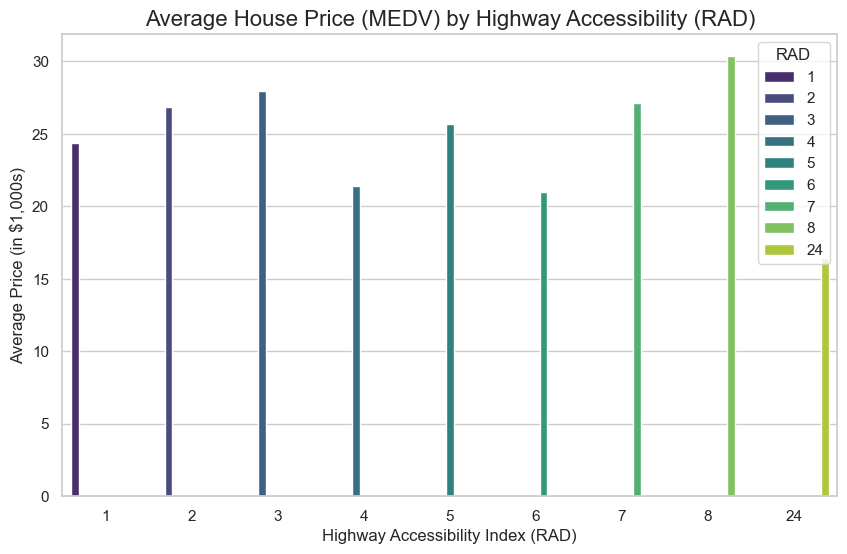

In [9]:
# 1. Bar Plot: Average House Price by Highway Accessibility
plt.figure(figsize=(10, 6))

# Calculate average price per index level
avg_price_rad = df.groupby('RAD')['MEDV'].mean().reset_index()

# Plotting
sns.barplot(data=avg_price_rad, x='RAD', y='MEDV', palette='viridis', hue='RAD')

# Customization: Title, labels, and font sizes
plt.title('Average House Price (MEDV) by Highway Accessibility (RAD)', fontsize=16)
plt.xlabel('Highway Accessibility Index (RAD)', fontsize=12)
plt.ylabel('Average Price (in $1,000s)', fontsize=12)

# Export the plot as a high-resolution image
plt.savefig('medv_by_rad_bar.png', dpi=300, bbox_inches='tight')
plt.show()

4. Create a Scatter Plot (Correlation Analysis)

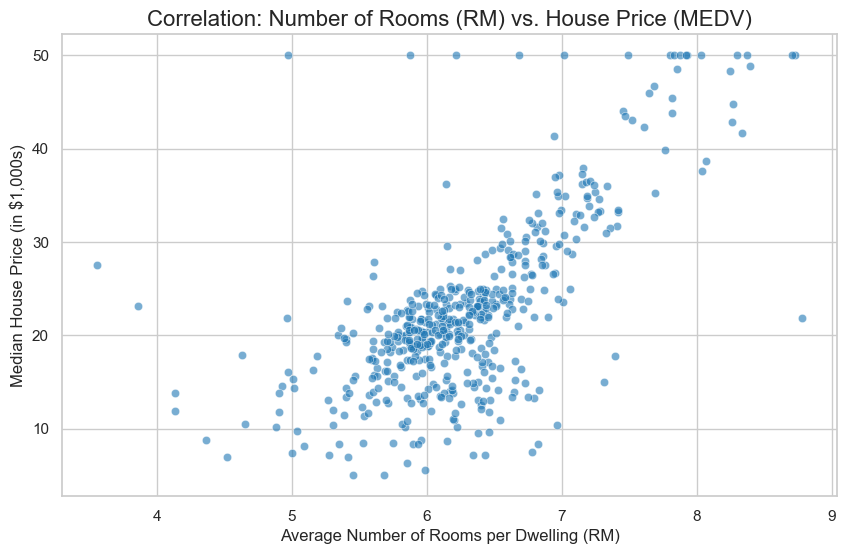

In [10]:
# 2. Scatter Plot: Rooms vs. House Price
plt.figure(figsize=(10, 6))

# Generate scatter plot with customized transparency and color
sns.scatterplot(data=df, x='RM', y='MEDV', alpha=0.6, color='tab:blue')

# Customization: Descriptive labels and title
plt.title('Correlation: Number of Rooms (RM) vs. House Price (MEDV)', fontsize=16)
plt.xlabel('Average Number of Rooms per Dwelling (RM)', fontsize=12)
plt.ylabel('Median House Price (in $1,000s)', fontsize=12)

# Export plot
plt.savefig('rm_vs_medv_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

5. Create a Line Chart (Trend Analysis)

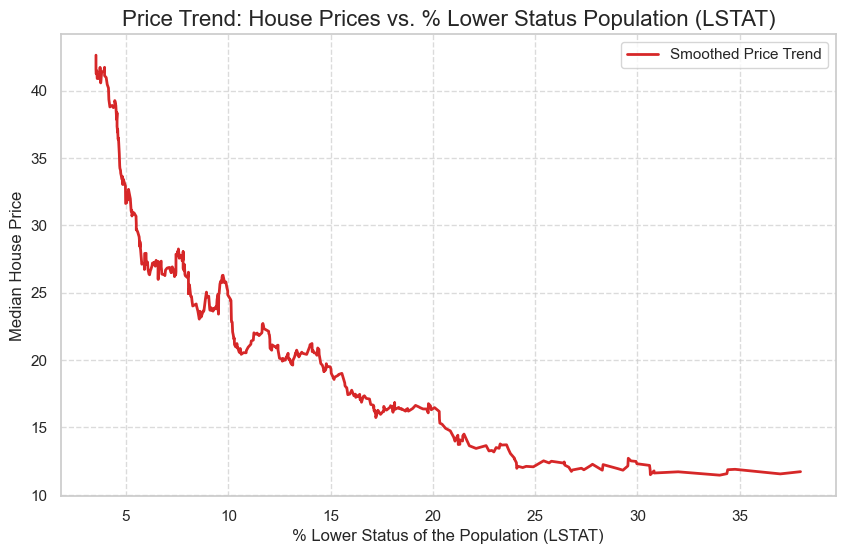

In [11]:
# 3. Line Chart: House Prices Trend as % Lower Status Increases
plt.figure(figsize=(10, 6))

# Sorting by LSTAT to show a smooth trend
trend_data = df.sort_values('LSTAT')

# Plotting a 20-sample rolling mean to smooth the visual trend line
plt.plot(trend_data['LSTAT'], trend_data['MEDV'].rolling(window=20).mean(), 
         color='tab:red', linewidth=2, label='Smoothed Price Trend')

# Customization: Title, labels, and grid
plt.title('Price Trend: House Prices vs. % Lower Status Population (LSTAT)', fontsize=16)
plt.xlabel('% Lower Status of the Population (LSTAT)', fontsize=12)
plt.ylabel('Median House Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Export plot
plt.savefig('lstat_vs_medv_line.png', dpi=300, bbox_inches='tight')
plt.show()